In [52]:
import numpy as np
import json
import csv
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

import matplotlib.font_manager as font_manager
import matplotlib
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']

# Plot outlet sharing distribution in 2D (Figs. 2D/E/F, 3 C/E)

In [53]:
edgelist = pd.read_csv('./data/shares_pseudo.csv', dtype = str)
edgelist = edgelist.drop_duplicates(subset = ['tweet_id'])

In [55]:
party_positions = pd.read_csv('./data/party_pos_FINAL.csv')

In [56]:
user_embedding = './data/embedding_pseudo.csv'

user_emb_df = pd.read_csv(user_embedding, dtype = str)
user_emb_df = user_emb_df.set_index('user')

user_list = list(edgelist.user)
pos_dict = user_emb_df.T.to_dict('list')

/var/folders/_p/7vwplj9155x7q1tghmrxfnlr0000gp/T/ipykernel_17165/1104390507.py:7: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  pos_dict = user_emb_df.T.to_dict('list')


In [57]:
pos_list_x = []
pos_list_y = []

ct = 0
ne_ct=0

for user_id in tqdm(user_list):
    if user_id in pos_dict.keys():
        pos_list_x.append(pos_dict[user_id][0])
        pos_list_y.append(pos_dict[user_id][1])
        ct +=1
    else:
        pos_list_x.append('not_embedded')
        pos_list_y.append('not_embedded')
        ne_ct +=1

edgelist['x'] = pos_list_x
edgelist['y'] = pos_list_y

100%|██████████████████████████████| 542764/542764 [00:00<00:00, 1875753.17it/s]


### PLOT

In [58]:
def plot_outlet_distribution(outlet, edgelist, pol_df, follower_color, follower_alpha, hist_alpha, density=True):
    
    edgelist = edgelist[edgelist['outlet'] == outlet]
    
    FOLLOWER_COLOR = follower_color
    FOLLOWER_ALPHA = follower_alpha
    STORY_COLOR_MEAN = "red"    
    
    title = outlet + ': Outlet sharing distribution'
    
    x = list(edgelist['x'])
    y = list(edgelist['y'])
    x = [float(s) for s in x if s!='not_embedded']
    y = [float(s) for s in y if s!='not_embedded']
    mean_x = sum(x)/len(x)
    mean_y = sum(y)/len(y)    
    pol_df['0'] = pol_df['0'].astype(float)
    pol_df['2'] = pol_df['2'].astype(float)
    x_mp = list(pol_df['0'])
    y_mp = list(pol_df['2'])
    
    fig = plt.figure(figsize=(10,10))
    
    gs = fig.add_gridspec(2, 2,  width_ratios=(7, 1), height_ratios=(1, 7),
                          left=0.1, right=0.9, bottom=0.1, top=0.9,
                          wspace=0.005, hspace=0.005)
    
    ## define axes
    ax = fig.add_subplot(gs[1, 0])
    ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
    ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)    
    
    if density == True:
        plot = sns.kdeplot(x=x, y=y, levels=20, cmap="Blues", 
                    fill = False,alpha = 1, zorder = 2, ax=ax)
        
        sharer_patch = Line2D([0], [0], color=follower_color, 
                       markerfacecolor=follower_color)
        
    else:
        plot = ax.scatter(x=x, y=y, c=FOLLOWER_COLOR, 
                    alpha = .1, zorder = 2, marker = 'x')
    #smean = ax.scatter(mean_x, mean_y, c = 'red', marker = 'x', s = 150, zorder = 3)
    colorlist = list(pol_df['color'])
    pol_df.plot(kind='scatter', x = '0', y = '2', c = colorlist, zorder = 3, 
                marker = 'o', ax=ax, edgecolors='black', s = 50,
                     alpha = 0.7,)    
    
#     ax.set_title(outlet + ': Outlet sharing distribution')
    
    ## title and axis labels
    ax.set_title(title, 
                       fontsize = 20,
                       loc='left',
                       fontdict = {'weight':'bold'},
                       x=0.02, y=0.93)    
    
    ax.set_xlabel('Left-right', fontsize = 17)
    ax.set_ylabel('Elite-/EU-skeptical/Protectionist', fontsize = 17)
    ax.set_ylim(-2,4)
    ax.set_xlim(-3,3)    
    
    ## define and draw histograms
    binwidth = 0.05
    xymax = max(np.max(np.abs(x)), np.max(np.abs(y)))
    lim = (int(xymax/binwidth) + 1) * binwidth
    bins = np.arange(-lim, lim + binwidth, binwidth)    
    ax_histx.hist(x, bins=bins, density=False,color=FOLLOWER_COLOR,alpha=hist_alpha)
    ax_histy.hist(y, bins=bins, orientation='horizontal',color=FOLLOWER_COLOR,alpha=hist_alpha)                
    
    ## some details
    ax_histx.axis('off')
    ax_histy.axis('off')
    ax.grid(alpha=.3)
    ax.tick_params(direction='in',which='both',width=1,top=True,right=True)
    ax.tick_params(direction='in',which='major',width=1,length=10)
    ax.tick_params(direction='in',which='minor',width=1,length=5)    
    
    ## add a custom legend element for the party positions
    patch = Line2D([0], [0], marker='o', color='w', 
                   markerfacecolor='w', markeredgecolor='black', markersize=7)
    
    ## define legend
    if density == True:
        legend = ax.legend([sharer_patch, patch],
                           ('Distribution of shares', 'Party position'),
                           loc=(0.03, 0.05),
                          )
    else:
        legend = ax.legend([plot, patch],
                           ('Outlet sharers', 'Party position'),
                           loc=(0.03, 0.05),
                          )        
    
    # make sure all legend markers have the same size
    for marker_idx in range(2):
        legend.legend_handles[marker_idx]._sizes = [50]
    for i in range(7):
        if i != 3:
            ax.get_xticklabels()[i].set_color("white")
    for i in range(7):
        if i != 2:
            ax.get_yticklabels()[i].set_color("white")
    
    name = './distribution-' + str(outlet) + '.pdf'
    plt.savefig(name, dpi = 300)
    plt.show()
    plt.close()
    
    return None    

/var/folders/_p/7vwplj9155x7q1tghmrxfnlr0000gp/T/ipykernel_17165/2516917980.py:97: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  legend.legendHandles[marker_idx]._sizes = [50]


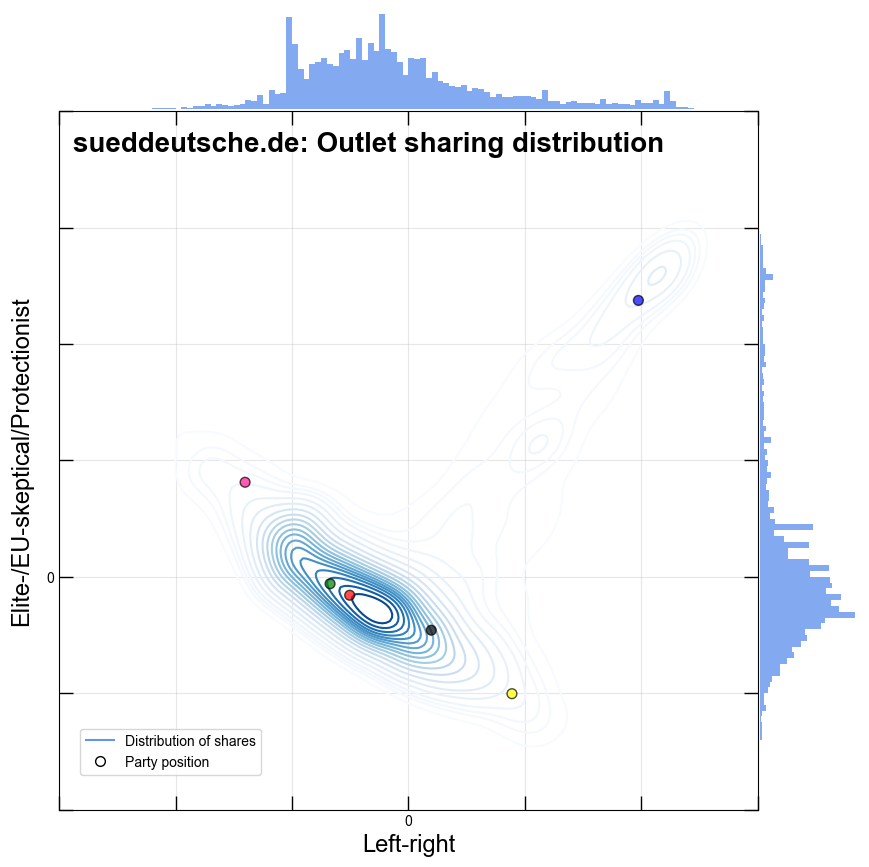

In [59]:
plot_outlet_distribution('sueddeutsche.de',
                    edgelist,
                    party_positions,
                    #partycol_list,
                    follower_color='#6495ED',
                    follower_alpha=.4,
                    hist_alpha=.8,
                    density=True)
